Método do Cotovelo

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans


In [ ]:
# Carrega o dataset
df = pd.read_csv("..\datasets\spotify_processed.csv", encoding='utf-8', low_memory=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Allan\AppData\Local\Temp\ipykernel_18788\4169275334.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\datasets\spotify_processed.csv", encoding='utf-8', low_memory=True)


In [ ]:
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo'
]
X = df[CLUSTER_FEATURES]


In [8]:
wcss = {}
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X[CLUSTER_FEATURES])
    wcss[k] = kmeans.inertia_

In [9]:
kneedle = KneeLocator(
    x=list(wcss.keys()),
    y=list(wcss.values()),
    curve='convex',
    direction='decreasing'
)
optimal_k = kneedle.elbow

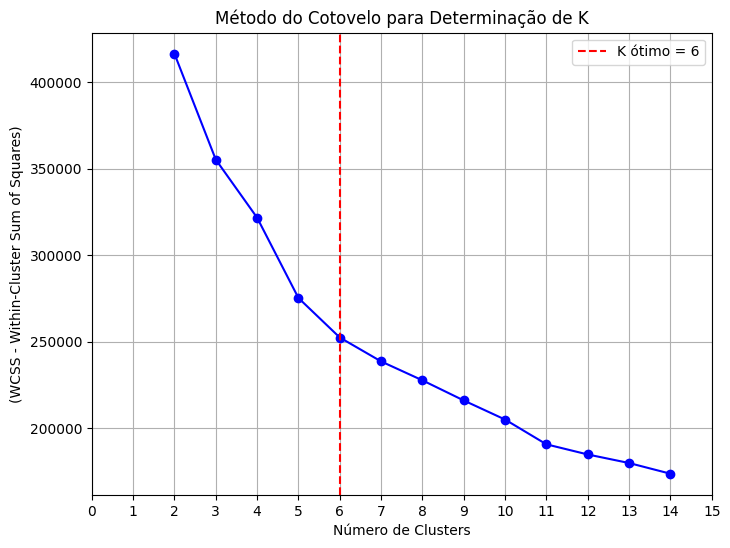

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(list(wcss.keys()), list(wcss.values()), 'bo-')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'K ótimo = {optimal_k}')
plt.xlabel('Número de Clusters')
plt.xticks(range(0,16))
plt.ylabel('(WCSS - Within-Cluster Sum of Squares)')
plt.title('Método do Cotovelo para Determinação de K')
plt.legend()
plt.grid(True)
plt.show()